Importing Required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os , warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Load The Dataset

In [2]:
import pandas as pd
df = pd.read_csv("Sales_Performance_Dataset.csv")
display(df.head())
print("dataset shape:", df. shape)

,InvoiceNo,StockCode,Description,Category,Quantity,UnitPrice,InvoiceDate,CustomerID,Age,Gender,Country,SalesRep,ReturnFlag,Total
0,INV168777,P0139,Product 139 - damaged,Fashon,5,873.93,45145,C004539,60.0,Female,Austalia,SR014,0,4369.65
1,INV172125,P0168,Product 168,electronisc,4,625.62,09-03-2023 19:45,C001993,40.0,Female,USA,SR015,0,2502.48
2,INV140531,P0135,Product 135,Health,6 units,376.26,45027,C004965,20.0,Male,Germany,SR006,0,2257.56
3,INV193354,P0075,Product 75,Home Decor,4,962.97,05-12-2023 01:33,C003444,25.0,Male,U S A,SR014,0,"$3,851.88 USD"
4,INV119476,P0012,Product 12,Fashon,9,35.23,25-02-2023 11:19,C002687,61.0,Male,Canada,SR018,0,317.07


dataset shape: (4999, 14)


Inspect Dataset Structure

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print("\nDataset Values")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (4999, 14)

Column Names:

Dataset Values
<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4999 non-null   str    
 1   StockCode    4999 non-null   str    
 2   Description  4895 non-null   str    
 3   Category     4999 non-null   str    
 4   Quantity     4999 non-null   str    
 5   UnitPrice    4999 non-null   str    
 6   InvoiceDate  4999 non-null   str    
 7   CustomerID   4728 non-null   str    
 8   Age          4863 non-null   float64
 9   Gender       4901 non-null   str    
 10  Country      4999 non-null   str    
 11  SalesRep     4999 non-null   str    
 12  ReturnFlag   4916 non-null   str    
 13  Total        4999 non-null   str    
dtypes: float64(1), str(13)
memory usage: 546.9 KB

Missing Values:
InvoiceNo        0
StockCode        0
Description    104
Category         0
Quantity         0
UnitPrice   

Prepare Invoice Date

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],format="mixed",errors="coerce")
print("Minimum Invoicedate:", df["InvoiceDate"].min())
print("Maximum InvoiceDate:",df["InvoiceDate"].max())
print("Missing dates:", df["InvoiceDate"].isna().sum())

Minimum Invoicedate: 2023-01-01 03:38:00
Maximum InvoiceDate: 2023-12-31 23:00:00
Missing dates: 768


Creat RFM  table

In [5]:
reference_date = df["InvoiceDate"].max()+ pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(
     Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
     Frequency=("InvoiceDate", "count"),
     Monetary=("Total","sum")
).reset_index()
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,1012,52.0,1,3706.26
1,1052,363.0,1,7963.47
2,1065,190.0,1,3616.88
3,1067,215.0,1,4374.72
4,1092,172.0,1,198.58


Descriptive Statistics

In [6]:
df["Total"] = (df["Total"].astype(str).str.replace(r"[^\d.-]", "",regex=True))
df["Total"] = pd.to_numeric(df["Total"], errors="coerce")
rfm["Monerary"] = rfm["Monetary"].astype(str).str.replace(r"[^\d.-]", "", regex=True)
rfm["Monetary"] = pd.to_numeric(rfm["Monetary"], errors="coerce")
print("Average Purchase Value:", df["Total"].mean())
print("Average Purchase Frequency:",rfm["Frequency"].mean())
print("Average Customer Monetary Value:",rfm["Monetary"].mean())

Average Purchase Value: 2371.235301060212
Average Purchase Frequency: 1.2237804878048781
Average Customer Monetary Value: 225811.68859629455


Check RFM Distributions

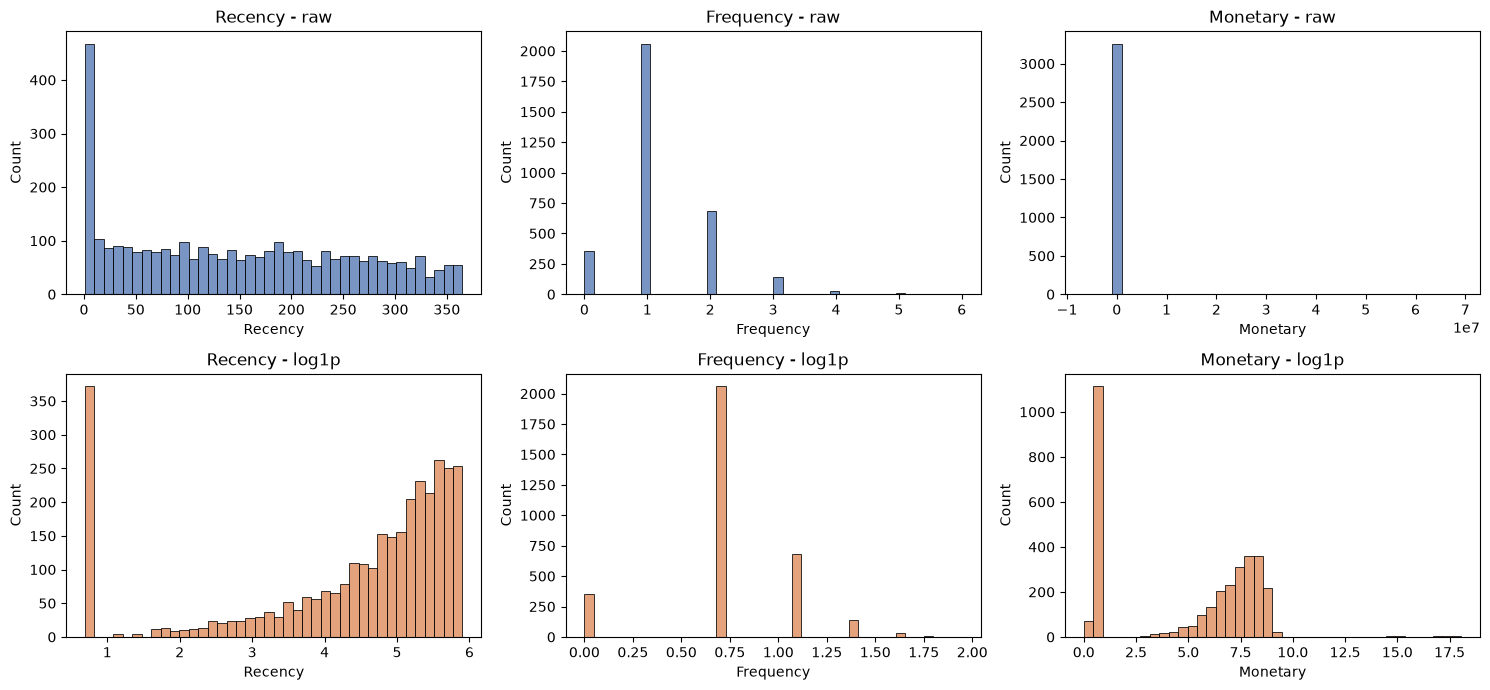

In [7]:

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, col in enumerate(["Recency","Frequency","Monetary"]):
    clean_series = rfm[col].astype(str).str.replace(r"[^\d.-]", "", regex=True)
    clean_series = pd.to_numeric(clean_series, errors="coerce").fillna(1)
    sns.histplot(clean_series, bins=40,ax=axes[0,i], color="#4c72b0")
    axes[0, i].set_title(f"{col} - raw")
    log_data = np.log1p(clean_series.clip(lower=0))
    sns.histplot(log_data, bins= 40, ax=axes[1,i],color="#DD8452")
    axes[1,i].set_title(f"{col} - log1p")
plt.tight_layout();
plt.show() 

Obesrevation

recency,Frequency,andMonetary values are highly skewed in the raw data log transaformation reduces  the skewness and makes the data more sutible for clustering

Standardisatuion

In [8]:
rfm_log = np.log1p(rfm[["Recency","Frequency","Monetary"]])
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
print("Meanafter scaling:",np.round(X.mean(axis=0),3))
print("Std after scaling:",np.round(X.std(axis=0),3))
pd.DataFrame(X, columns=["recency","Frequency","Monetary"]).describe().round(2)
      

Meanafter scaling: [nan  0. nan]
Std after scaling: [nan  1. nan]


C:\Users\kisho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


,recency,Frequency,Monetary
count,2925.00,3280.00,2094.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-4.08,-2.19,-3.23
25%,-0.45,-0.15,-0.53
50%,0.31,-0.15,0.10
75%,0.75,1.05,0.57
max,1.12,3.54,7.45


K-Means and the Elbow Method

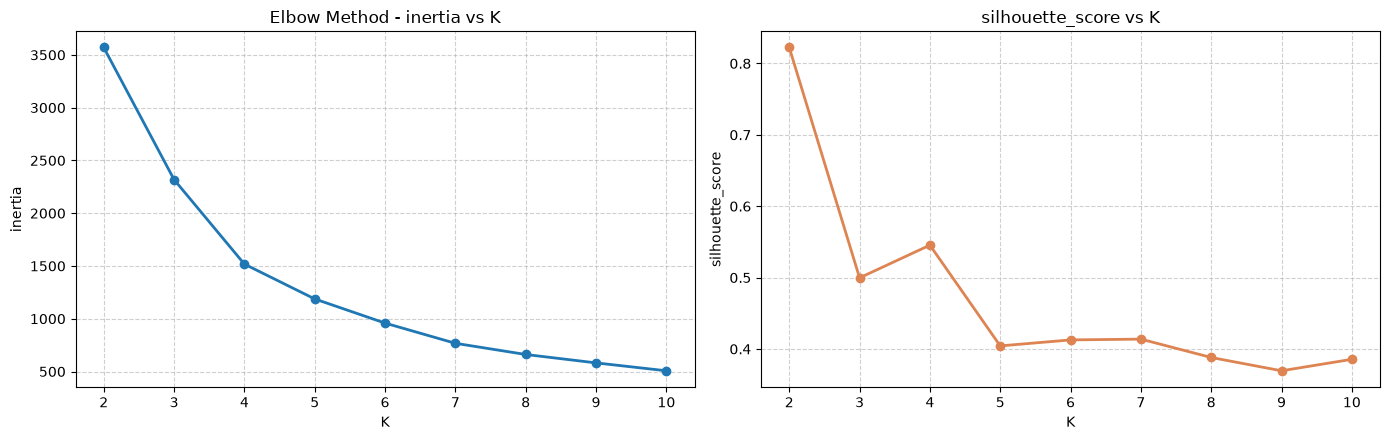

K   | inertia      | silhouette _score
2   | 3570.1       | 0.822
3   | 2318.4       | 0.500
4   | 1517.7       | 0.545
5   | 1187.7       | 0.404
6   | 958.8        | 0.413
7   | 767.4        | 0.414
8   | 661.4        | 0.388
9   | 581.8        | 0.369
10  | 507.0        | 0.386


In [9]:
rfm_features = rfm[["Recency","Frequency","Monetary"]].dropna()
rfm_log = np.log1p(rfm_features.clip(lower=0))

scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)

RANDOM_STATE = 42
K_range = range(2,11)
inertia, sil = [],[]
for k in K_range:
    km = KMeans(n_clusters=k,random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))
fig,axes = plt.subplots(1,2, figsize=(14, 4.5))
axes[0].plot(list(K_range), inertia, marker="o", lw=2)
axes[0].set_title("Elbow Method - inertia vs K");
axes[0].set_xlabel("K")
axes[0].set_ylabel("inertia")
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(list(K_range), sil, marker="o", lw=2, color="#DD8452")
axes[1].set_title("silhouette_score vs K");
axes[1].set_xlabel("K");
axes[1].set_ylabel("silhouette_score")
axes[1].grid(True, linestyle="--",alpha=0.6)

plt.tight_layout()
plt.show()

print(f"{'K' :<3} | {'inertia':<12} | {'silhouette _score':<12}")
for k, i, s in zip (K_range, inertia, sil):
    print(f"{k:<3} | {i:<12.1f} | {s:.3f}")



Observation

The Elbow Method suggests K=4 as the optional number of clusters the silhouette Score is highest at K=2,butK=4 provides usefull
detailed segmentation

In [10]:
rfm_clean = rfm.dropna(subset=["Recency","Frequency","Monetary"]).copy()
rfm_log = np.log1p(rfm_clean[["Recency","Frequency","Monetary"]].clip(lower=0))
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
K = 4
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
rfm_clean["Cluster"] = kmeans.fit_predict(X)
print("silhouette score at k=4:",
round(silhouette_score(X, rfm_clean["Cluster"]), 3))
print(rfm_clean["Cluster"].value_counts(). sort_index())      

silhouette score at k=4: 0.386
Cluster
0    400
1     17
2     88
3     57
4    206
5    138
6     13
7    375
8      4
9    547
Name: count, dtype: int64


Visualizing the Clusters

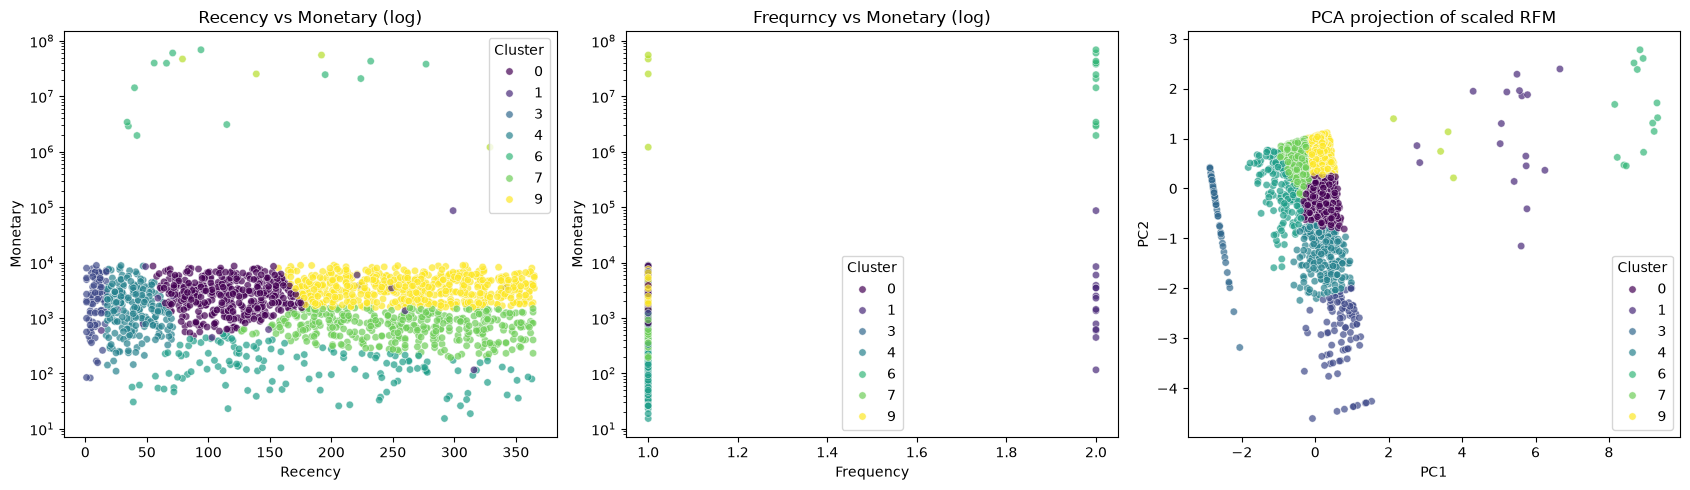

In [11]:
fig, axes = plt.subplots(1,3, figsize=(17, 5))
sns.scatterplot(data=rfm_clean, x="Recency",y="Monetary", hue="Cluster",palette="viridis", alpha=.7, s=28,ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Recency vs Monetary (log)")
sns.scatterplot(data=rfm_clean, x="Frequency",y="Monetary", hue="Cluster", palette="viridis", alpha=.7,s=28, ax=axes[1],)
axes[1].set_yscale("log")
axes[1].set_title("Frequrncy vs Monetary (log)")
pcs = PCA(n_components=2,random_state=RANDOM_STATE).fit_transform(X)
sns.scatterplot(x=pcs[:, 0],y=pcs[:, 1], hue=rfm_clean["Cluster"],palette="viridis",alpha=0.7,s=28,ax=axes[2])
axes[2].set_title("PCA projection of scaled RFM")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
plt.tight_layout()
plt.show()

Observation

Low purchases frequency dominates the dataset (1-2 trasations),yet PCA shows distinct,well-separated cluster groups across gropus
across the RFM features 

Cluster profiling

In [12]:
profile =( rfm_clean.groupby("Cluster").
  agg(
     Recency_mean = ("Recency", "mean"),
     Frequency_mean = ("Frequency", "mean"),
     Monetary_mean = ("Monetary", "mean"),
     Monetary_total = ("Monetary", "sum"),
     Customers = ("Recency", "size"),
).round(1)
)
profile["% of customers"] = (profile["Customers"]/profile["Customers"].sum()* 100).round(1)
profile["% of revenue"] = (profile["Monetary_total"]/ profile["Monetary_total"].sum()*100).round(1)

r_rank = profile["Recency_mean"].rank()
f_rank = profile["Frequency_mean"].rank(ascending=False)
m_rank = profile["Monetary_mean"].rank(ascending=False)
score = r_rank + f_rank + m_rank

order = score.sort_values().index
names = ["champions","Loyal Customers","Occasional Buyers", "At-Risk / Hibernating"]
name_map = {cl: nm for cl, nm in zip (order, names[:len(order)])}
profile["Segment"] = profile.index.map (name_map)
rfm_clean["Segment"] = rfm_clean["Cluster"].map(name_map)

profile[["Segment", "Recency_mean", "Frequency_mean","Monetary_mean","Customers", "% of customers","% of revenue"]]

,Segment,Recency_mean,Frequency_mean,Monetary_mean,Customers,% of customers,% of revenue
Cluster,,,,,,,
0,At-Risk / Hibernating,116.6,1.0,3082.4,400,21.7,0.3
1,NaN,158.5,2.0,-382949.4,17,0.9,-1.3
2,Loyal Customers,9.0,1.0,3029.8,88,4.8,0.1
3,NaN,195.7,1.0,-1280.6,57,3.1,-0.0
4,Occasional Buyers,39.2,1.0,2028.9,206,11.2,0.1
5,NaN,183.1,1.0,169.9,138,7.5,0.0
6,champions,113.9,2.0,27799120.8,13,0.7,74.0
7,NaN,260.0,1.0,777.1,375,20.3,0.1
8,NaN,184.8,1.0,32302784.2,4,0.2,26.5


C:\Users\kisho\AppData\Local\Temp\ipykernel_12280\1458141934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=axes[0],palette="Set2")
C:\Users\kisho\AppData\Local\Temp\ipykernel_12280\1458141934.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rev.values, y=rev.index, ax=axes[1], palette="Set2")


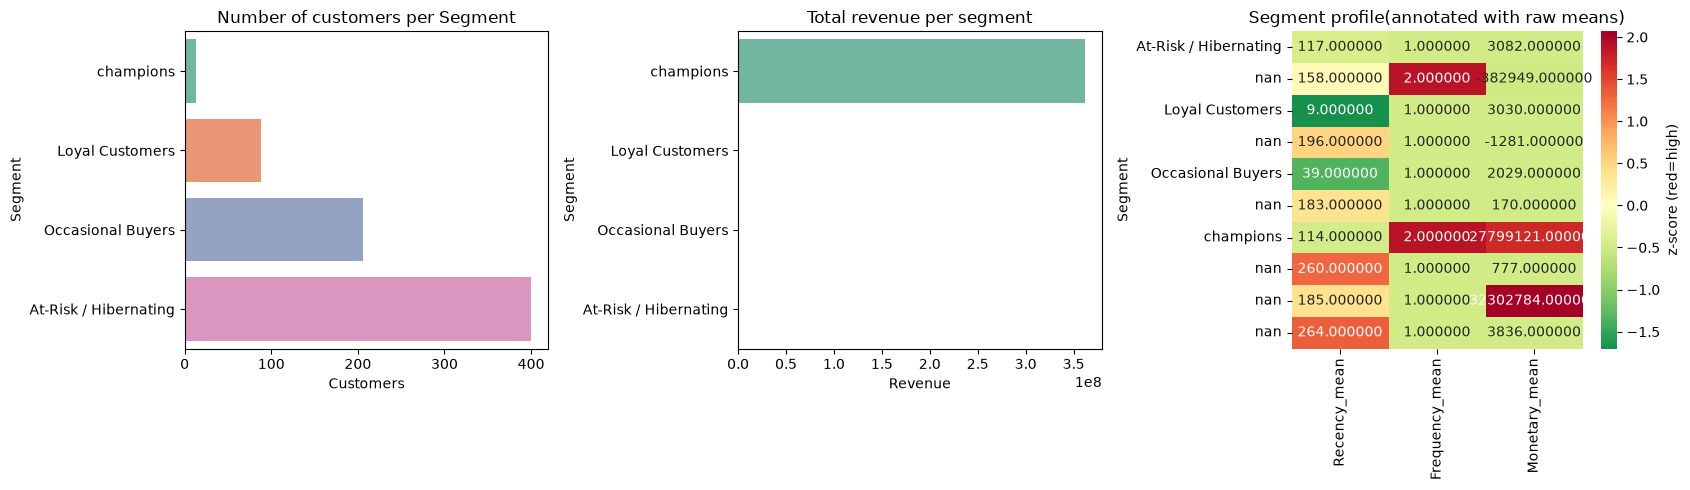

In [13]:
fig, axes = plt.subplots(1,3, figsize=(17,5))
counts = rfm_clean["Segment"].value_counts().reindex(names).dropna()
sns.barplot(x=counts.values, y=counts.index, ax=axes[0],palette="Set2")
axes[0].set_title("Number of customers per Segment"); 
axes[0].set_xlabel("Customers")

rev = rfm_clean.groupby("Segment")["Monetary"].sum() .reindex(counts.index)
sns.barplot(x=rev.values, y=rev.index, ax=axes[1], palette="Set2")
axes[1].set_title("Total revenue per segment");axes[1].set_xlabel("Revenue")

heat = profile.set_index("Segment")[["Recency_mean","Frequency_mean","Monetary_mean"]]
heat_z = (heat - heat.mean())/ heat.std()
sns.heatmap(heat_z, annot=heat.round(0), fmt="0f", cmap="RdYlGn_r", center=0, ax=axes[2],cbar_kws={"label": "z-score (red=high)"},)
axes[2].set_title("Segment profile(annotated with raw means)")
plt.tight_layout()
plt.show()

Observation

AT-RISK/Hibernating customers from the largest customer segment,with around 400 Customers.
Occasional Buyers are the second-largest group,with around 200 Customers.
loyalCustomers are comparatively fewer,with around 90 Customers.

there are servel"NaN" values in the heatmap,indicating missing or unavailablesegment data

overall,the business shouid focus on retaining high-value customers and converting At-risk customers into active customers